# Surface plasmon illustration with PyMoosh

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import PyMoosh as PM
from PyMoosh.modes import guided_modes, complex_map
from scipy import signal


font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

In [2]:
# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
w = 5690*8.118 # the waist before reflection corresponding to the experimental setup defined

# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
h_Au = 47
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000*5, 2, h_Au, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

BK7 = PM.Material("BK7")
print(np.sqrt(np.abs(BK7.get_permittivity(wavelength))))

Pixels horizontally: 46191
Incidence in degrees: 73.38000000000001
H//, TM, p polarization
Pixels vertically: 2104


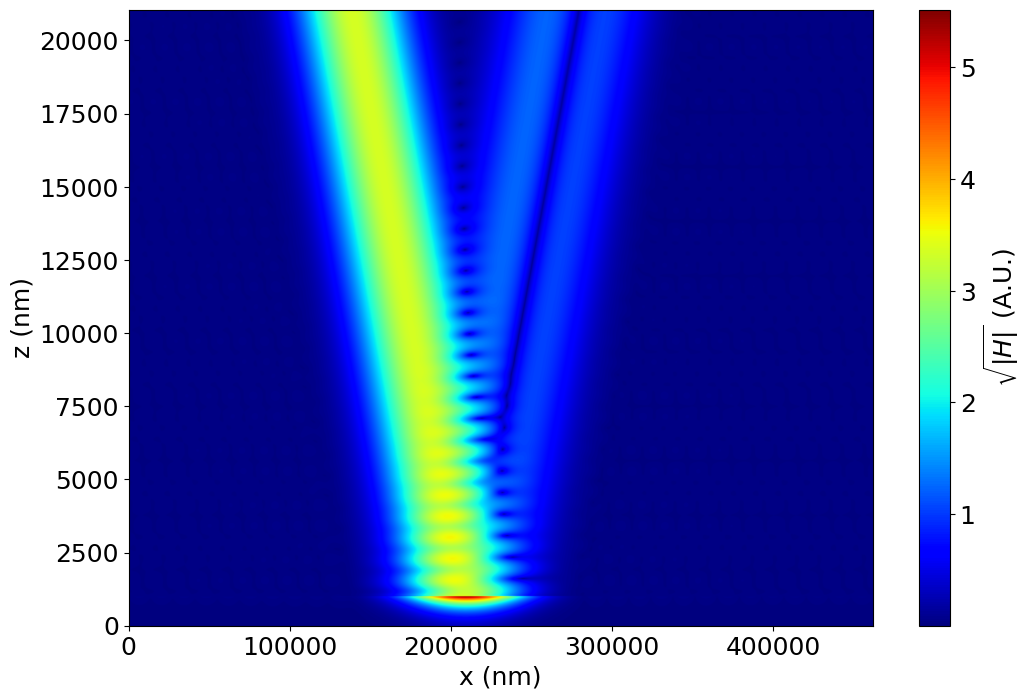

In [3]:
window = PM.Window(w*10, 0.3,10 , 10)
beam = PM.Beam(wavelength, 73.38*np.pi/180, 1, w/2)
H = PM.field(structure,beam,window)

plt.figure(figsize=(12, 8))
plt.imshow(np.abs(H)**0.5,cmap='jet',extent=[0,window.width,0,sum(structure.thickness)],aspect='auto')
# plt.imshow(np.real(H)*(np.real(H)>0),cmap='jet',extent=[0,window.width,0,sum(structure.thickness)],aspect='auto')
# plt.clim(0,0.04*np.max(np.abs(H)))
plt.xlabel('x (nm)')
plt.ylabel('z (nm)')
# plt.title('Illustration of interferences between the reflected beam and the surface plasmon')
cbar=plt.colorbar()
cbar.set_label(r'$\sqrt{|H|}$ (A.U.)');

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/surface_plasmon_illustration.{file_ext}", bbox_inches="tight")

In [4]:
mat = ["BK7",Cr,Au,1.33**2]
thickness = [4000, 2, h_Au, 1000]  # thickness of each layer
stack = [0, 1, 2, 3]
structure = PM.Structure(mat, stack, thickness, verbose=False)

[np.complex128(1.445057006585938+0.025251939785085335j), np.complex128(1.7395803616464474+0.1384020675540372j)]
3988.3370879902095


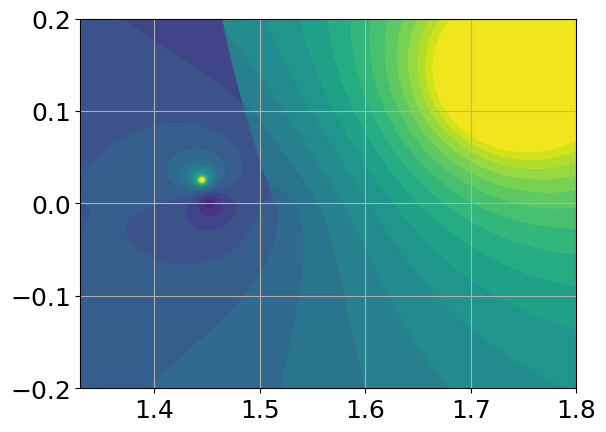

In [5]:
X,Y,T = complex_map(structure,wavelength,1,[1.33,1.8],[-0.2,0.2],500,500)
plt.contourf(X,Y,np.sqrt(np.real(T)*(np.real(T)<10)+10*(np.real(T)>=10)),levels=20)
plt.grid(True);

l_modes = guided_modes(structure,wavelength,1,1.4,1.5)
print(l_modes)
print(1/(np.imag(l_modes[0])*2*np.pi/wavelength))

Simple model of a Gaussian beam convolution with the reflection coefficient of our structure.

19.51951951951952
5.610501264151357e-06


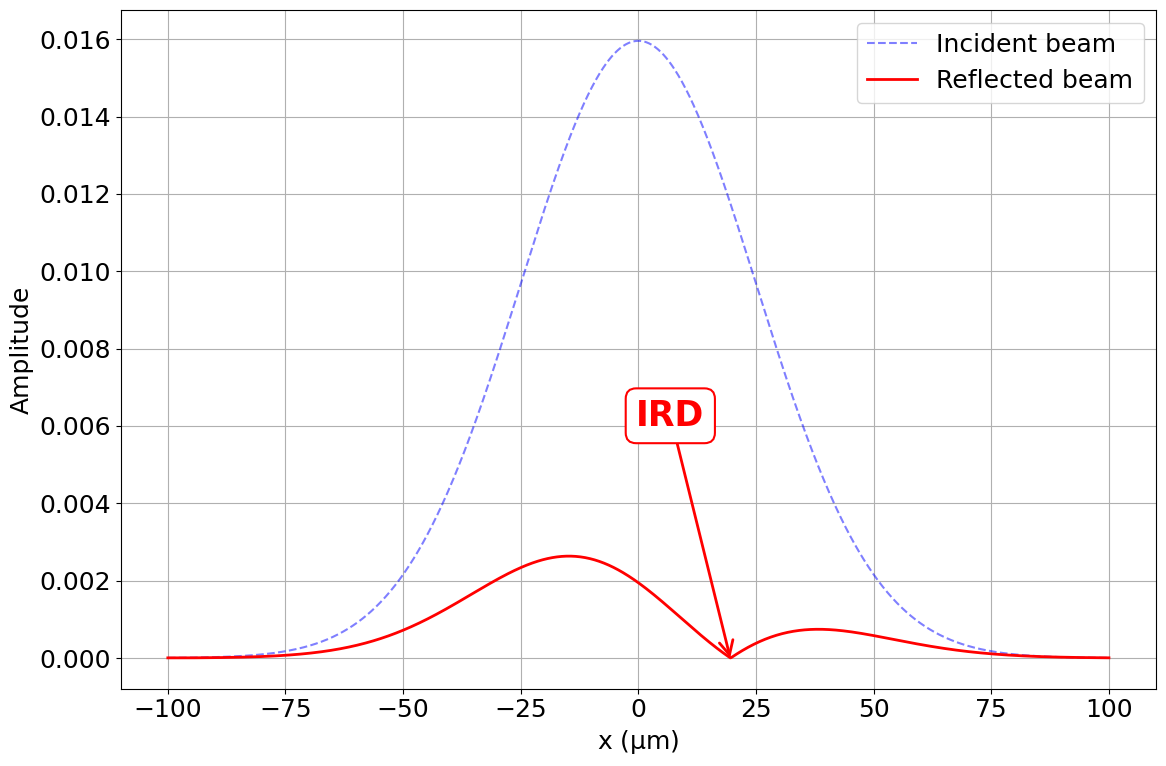

In [68]:
# Paramètres
n_points = 1000
x = np.linspace(-100, 100, n_points)
dx = x[1] - x[0]

# Gaussienne
mu = 0  # moyenne
sigma = 25  # écart-type si on dit que c'est 25 microns, euh...
gaussienne = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Exponentielle décroissante pour x > 0
tau = 4  # constante de décroissance
exponentielle = np.where(x >= 0, np.exp(-x / tau), 0)
# Normalisation de l'exponentielle
exponentielle = exponentielle / (np.sum(exponentielle) * dx)

# Convolution
convolution = signal.convolve(gaussienne, exponentielle, mode='same') * dx

z = np.abs(gaussienne - 0.9*convolution)
dip_index = np.argmin(z*(np.abs(x)<=2*sigma)+1000*z*(np.abs(x)>2*sigma))   # z is your reflected beam array
dip_x = x[dip_index]
dip_z = z[dip_index]

print(dip_x)
print(dip_z)
# Tracé des courbes
plt.figure(figsize=(12, 8))

plt.plot(x, gaussienne, 'b--', linewidth=1.5, alpha=0.5, label='Incident beam')
plt.plot(x, z, 'r-', linewidth=2, label='Reflected beam')
plt.grid()
plt.xlabel(r'x ($\rm{\mu}$m)')
plt.ylabel('Amplitude')
# plt.title('2D Beam model')
plt.legend()
plt.annotate('IRD',xy=(dip_x, dip_z),xytext=(dip_x-20, dip_z + 0.006),color='red',fontweight='bold',fontsize=25,
    arrowprops=dict(arrowstyle='->',color='red',lw=2,shrinkA=0,shrinkB=0),bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1.5))
plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/beam_convolution_illustration_w_50.{file_ext}", bbox_inches="tight")

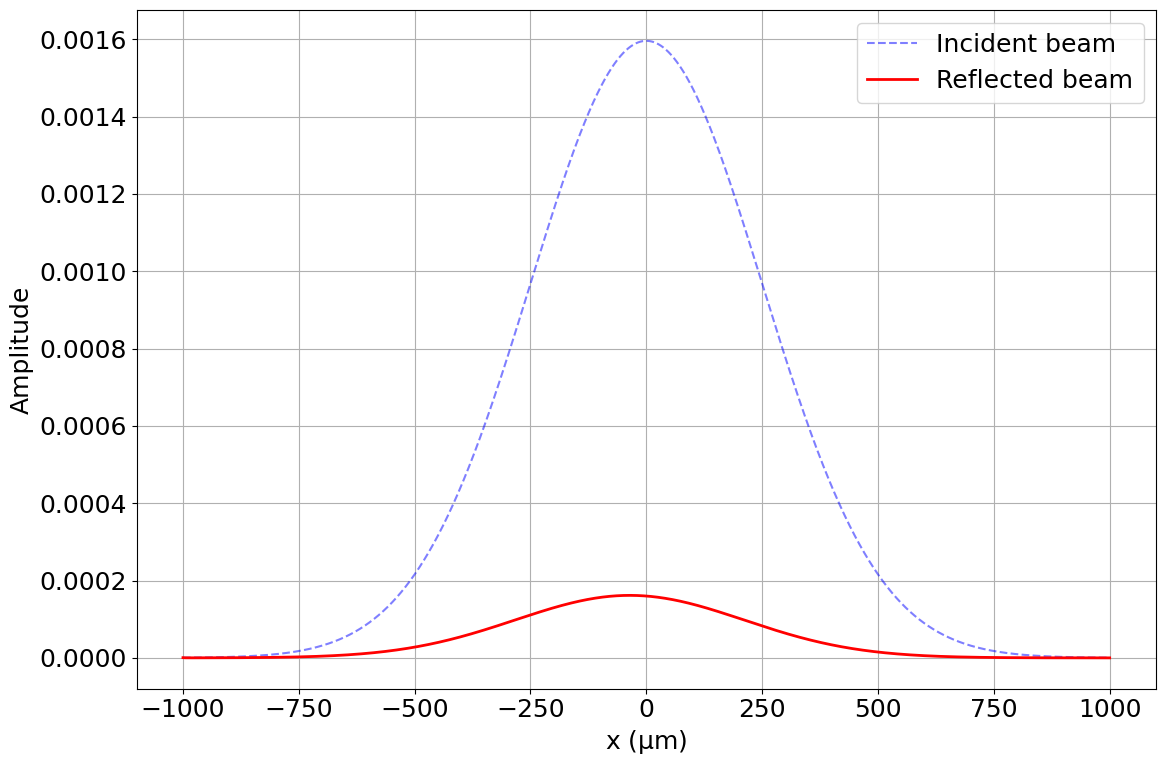

In [69]:
# Paramètres
n_points = 10000
x = np.linspace(-1000, 1000, n_points)
dx = x[1] - x[0]

# Gaussienne
mu = 0  # moyenne
sigma = 250  # écart-type si on dit que c'est 25 microns, euh...
gaussienne = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Exponentielle décroissante pour x > 0
tau = 4  # constante de décroissance
exponentielle = np.where(x >= 0, np.exp(-x / tau), 0)
# Normalisation de l'exponentielle
exponentielle = exponentielle / (np.sum(exponentielle) * dx)

# Convolution
convolution = signal.convolve(gaussienne, exponentielle, mode='same') * dx

z = np.abs(gaussienne - 0.9*convolution)

# Tracé des courbes
plt.figure(figsize=(12, 8))

plt.plot(x, gaussienne, 'b--', linewidth=1.5, alpha=0.5, label='Incident beam')
plt.plot(x, z, 'r-', linewidth=2, label='Reflected beam')
plt.grid()
plt.xlabel(r'x ($\rm{\mu}$m)')
plt.ylabel('Amplitude')
# plt.title('2D Beam model')
plt.legend()
plt.tight_layout();

if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/beam_convolution_illustration_w_500.{file_ext}", bbox_inches="tight")